In [1]:
import sys
sys.path.insert(0, r"C:\VisionAI\python_binding")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import vision_ai

X_train = np.load(r"C:\VisionAI\datasets\X_train.npy")
y_train = np.load(r"C:\VisionAI\datasets\y_train.npy")
X_test = np.load(r"C:\VisionAI\datasets\X_test.npy")
y_test = np.load(r"C:\VisionAI\datasets\y_test.npy")

CLASSES = ["aucun", "humain", "animal"]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print("Donnees chargees !")

Train : (1094, 12288)
Test  : (274, 12288)
Donnees chargees !


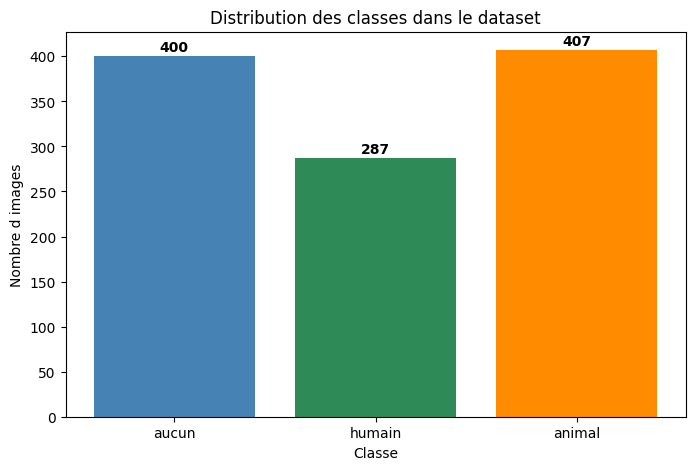


Statistiques du dataset :
  Dimensions images : 64x64x3 = 12288 valeurs
  Pixel min : 0.000
  Pixel max : 1.000
  Moyenne   : 0.452
  Ecart-type: 0.287


In [2]:
counts = [np.sum(y_train == i) for i in range(3)]

plt.figure(figsize=(8, 5))
plt.bar(CLASSES, counts, color=["steelblue", "seagreen", "darkorange"])
plt.title("Distribution des classes dans le dataset")
plt.ylabel("Nombre d images")
plt.xlabel("Classe")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.show()

print("\nStatistiques du dataset :")
print(f"  Dimensions images : 64x64x3 = {X_train.shape[1]} valeurs")
print(f"  Pixel min : {X_train.min():.3f}")
print(f"  Pixel max : {X_train.max():.3f}")
print(f"  Moyenne   : {X_train.mean():.3f}")
print(f"  Ecart-type: {X_train.std():.3f}")

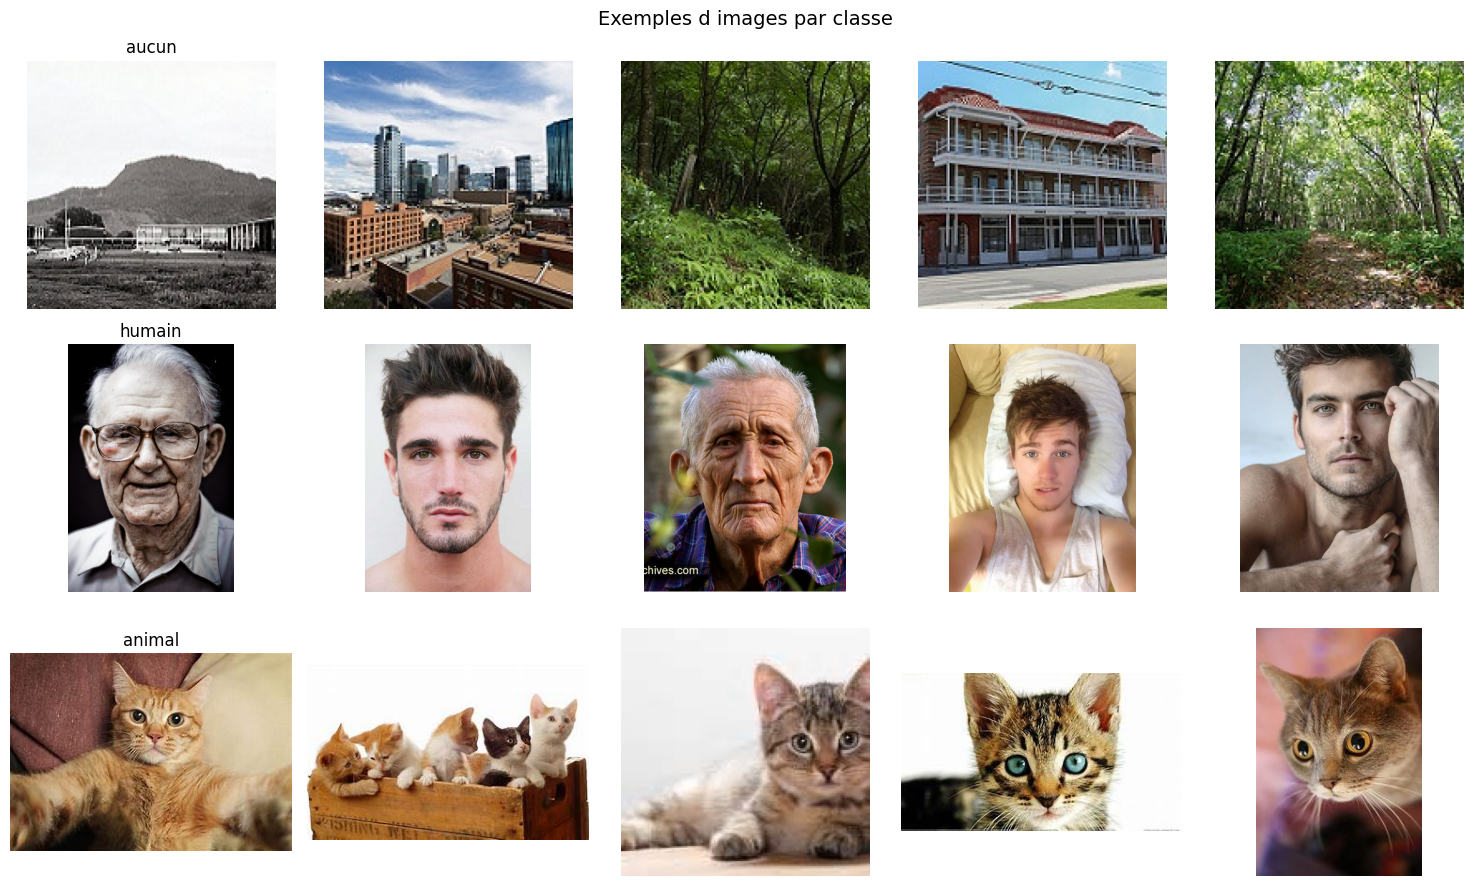

In [3]:
DATASET_DIR = r"C:\VisionAI\datasets\train"

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Exemples d images par classe", fontsize=14)

for row, classe in enumerate(CLASSES):
    dossier = os.path.join(DATASET_DIR, classe)
    fichiers = os.listdir(dossier)[:5]
    for col, fichier in enumerate(fichiers):
        chemin = os.path.join(dossier, fichier)
        try:
            img = mpimg.imread(chemin)
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(classe, fontsize=12)
        except:
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [4]:
print("Preparation des donnees...")

inputs_train = [X_train[i].tolist() for i in range(len(X_train))]
inputs_test = [X_test[i].tolist() for i in range(len(X_test))]

targets_train = []
for label in y_train:
    target = [0.0, 0.0, 0.0]
    target[int(label)] = 1.0
    targets_train.append(target)

print("Entrainement du MLP...")
model = vision_ai.PyMLP([12288, 64, 3])
model.train(inputs_train, targets_train, 0.001, 5)
print("Termine !")

Preparation des donnees...
Entrainement du MLP...
Termine !


In [5]:
predictions = [model.predict(x) for x in inputs_test]
y_pred = [pred.index(max(pred)) for pred in predictions]

correct = sum(1 for p, t in zip(y_pred, y_test) if p == int(t))
accuracy = correct / len(y_test) * 100

print(f"Accuracy sur le test : {accuracy:.1f}%")
print(f"Correct : {correct}/{len(y_test)}")

Accuracy sur le test : 33.9%
Correct : 93/274


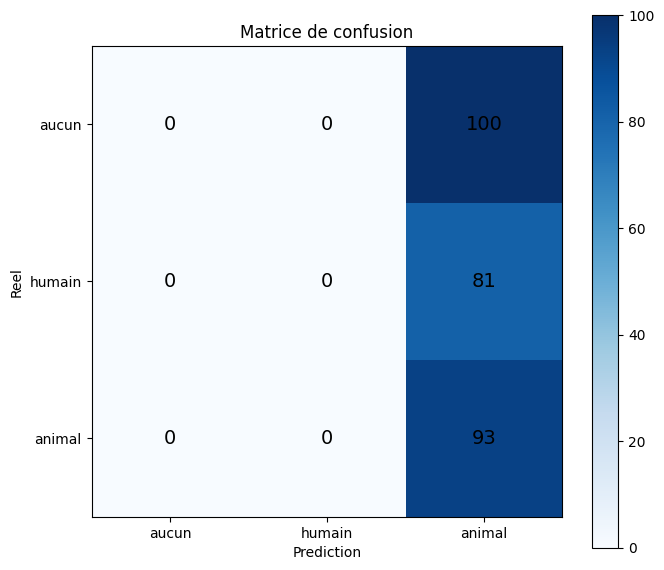

In [6]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test.astype(int), y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prediction")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion")

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [7]:
print("Analyse terminee !")
print(f"\nResume :")
print(f"  Dataset : {len(X_train) + len(X_test)} images au total")
print(f"  Train   : {len(X_train)} images")
print(f"  Test    : {len(X_test)} images")
print(f"  Classes : aucun, humain, animal")
print(f"  Accuracy MLP (5 epoques) : {accuracy:.1f}%")
print(f"\nNote : augmenter les epoques ameliore les resultats.")

Analyse terminee !

Resume :
  Dataset : 1368 images au total
  Train   : 1094 images
  Test    : 274 images
  Classes : aucun, humain, animal
  Accuracy MLP (5 epoques) : 33.9%

Note : augmenter les epoques ameliore les resultats.
